# Выгрузка и обработка датасета



In [ ]:
#Подгружаем библиотеки и датасет
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#train_transaction = pd.read_csv("train_transaction.csv")
#train_identity = pd.read_csv("train_identity.csv")

#print(train_transaction.shape, train_identity.shape)

sample_fraction = 0.3

print(f"Загрузка {sample_fraction*100}% данных...")
train_transaction = pd.read_csv('train_transaction.csv', skiprows=lambda i: i>0 and np.random.random() > sample_fraction)
train_identity = pd.read_csv('train_identity.csv')

print(f"Размер transaction: {train_transaction.shape}")
print(f"Размер identity: {train_identity.shape}")

Загрузка 30.0% данных...
Размер transaction: (177562, 394)
Размер identity: (144233, 41)


In [ ]:
#Объединяем части датасета и чистим
import gc
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

del train_transaction, train_identity
gc.collect()

0

Размер датасета: (177562, 434)


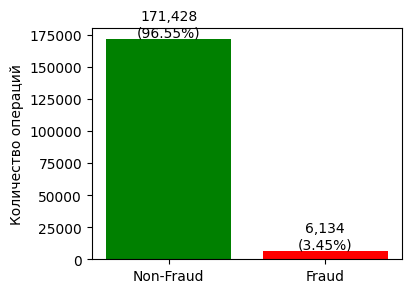

In [ ]:
print("Размер датасета:", df.shape)

plt.figure(figsize=(4, 3))
categories = ['Non-Fraud', 'Fraud']
counts = [len(df) - df['isFraud'].sum(), df['isFraud'].sum()]

bars = plt.bar(categories, counts, color=['green', 'red'])

for bar, count in zip(bars, counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{count:,.0f}\n({count/len(df)*100:.2f}%)', ha='center', va='bottom')

plt.ylabel('Количество операций')
plt.show()

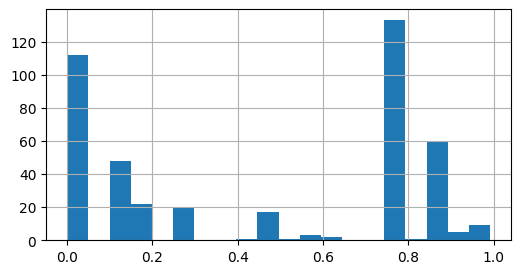

In [ ]:
#Процентрое соотношение пустых полей
missing_ratio = df.isnull().mean()

plt.figure(figsize=(6,3))
missing_ratio.hist(bins=20)
plt.show()

In [ ]:
#Удаляем пропуски и сторбец с id
df = df.drop(columns = missing_ratio[missing_ratio > 0.8].index)

print(f"Удалено столбцов: {len(missing_ratio[missing_ratio > 0.8].index)}. Где процент пропусков больше 80")

df = df.drop(columns=['TransactionID'])

Удалено столбцов: 74. Где процент пропусков больше 80


In [ ]:
#Удаляем почти константные признаки
quasi_constant_cols = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).values[0]
    if top_freq > 0.99:
        quasi_constant_cols.append(col)

df = df.drop(columns=quasi_constant_cols)

In [ ]:
df.shape

(177562, 344)

In [ ]:
#Выделяем столбец с меткой
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

y = df['isFraud']
X = df.drop(columns=['isFraud'])

#Делим признаки на котегореальные и дискретные
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

#Заполняем пропуски в обеих группах
for col in numeric_cols:
  X[col] = X[col].fillna(X[col].median())

label_encoders = {}
for col in categorical_cols:
    X[col] = X[col].fillna('Unknown')

    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le


In [ ]:
#Делим на тест и трейн части
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train fraud rate: 0.03454441777133243
Test fraud rate: 0.03455072790245826


# Логистическая регрессия

In [ ]:
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, average_precision_score
from sklearn.metrics import precision_recall_curve, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

def create_pipeline():
    steps = []
    steps.append(('scaler', StandardScaler())) # Масштабирование
    steps.append(('smote', SMOTE(random_state=42))) # Балансировка
    steps.append(('classifier', LogisticRegression(random_state=42))) #Классификатор
    return ImbPipeline(steps)

print("Обучение базовой модели:\n")

pipeline = create_pipeline()

print("Обучение логистической регрессии")
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# Оценка базовой модели
print("Результаты базовой модели:")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"pr_auc: {average_precision_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

Обучение базовой модели:

Обучение логистической регрессии


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Результаты базовой модели:
ROC-AUC: 0.8439
F1-Score: 0.2119
pr_auc: 0.3851

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.82      0.90     34286
       Fraud       0.12      0.71      0.21      1227

    accuracy                           0.82     35513
   macro avg       0.56      0.77      0.55     35513
weighted avg       0.96      0.82      0.87     35513



In [ ]:
#Строим оптимальную модель через подбор гиперпараметров
print("Подбор гиперпараметров\n")

# Создаем пайплайн для GridSearch
pipeline_grid = create_pipeline()

# Задаем сетку гиперпараметров
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10],  # параметр регуляризации
    'classifier__penalty': ['l2'],  # тип регуляризации
    'classifier__solver': ['liblinear', 'lbfgs'],  # алгоритм оптимизации
    'classifier__class_weight': ['balanced'],  # веса классов
    'smote__sampling_strategy': [0.1, 0.3, 0.5]  # соотношение классов после SMOTE
}

# Упрощенная сетка для экономии времени
param_grid_simple = {
    'classifier__C': [0.001, 0.01, 0.1, 1],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['liblinear'],
    'classifier__class_weight': ['balanced'],
    'smote__sampling_strategy': [0.1, 0.3, 0.5]
}

# Создаем GridSearchCV
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline_grid,
    param_grid_simple,  # используем сетку
    cv=cv_strategy,
    scoring='roc_auc',  # оптимизируем ROC-AUC
    n_jobs=-1,
    verbose=1
)

print("Поиск лучших гиперпараметров")
grid_search.fit(X_train, y_train)

# Лучшие параметры
print("\nЛучшие параметры:")
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")
print(f"Лучший ROC-AUC на кросс-валидации: {grid_search.best_score_:.4f}")

# Оценка
print("Оценка модели\n")

best_model = grid_search.best_estimator_

# Предсказания на тестовой выборке
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

Подбор гиперпараметров

Поиск лучших гиперпараметров
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Лучшие параметры:
classifier__C: 1
classifier__class_weight: balanced
classifier__penalty: l2
classifier__solver: liblinear
smote__sampling_strategy: 0.1
Лучший ROC-AUC на кросс-валидации: 0.8473
Оценка модели




Результаты оптимизированной модели:
ROC-AUC: 0.8465
F1-Score: 0.2166
pr_auc: 0.3892
Precision: 0.2166
Recall: 0.2166

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.83      0.90     34286
       Fraud       0.13      0.70      0.22      1227

    accuracy                           0.82     35513
   macro avg       0.56      0.77      0.56     35513
weighted avg       0.96      0.82      0.88     35513



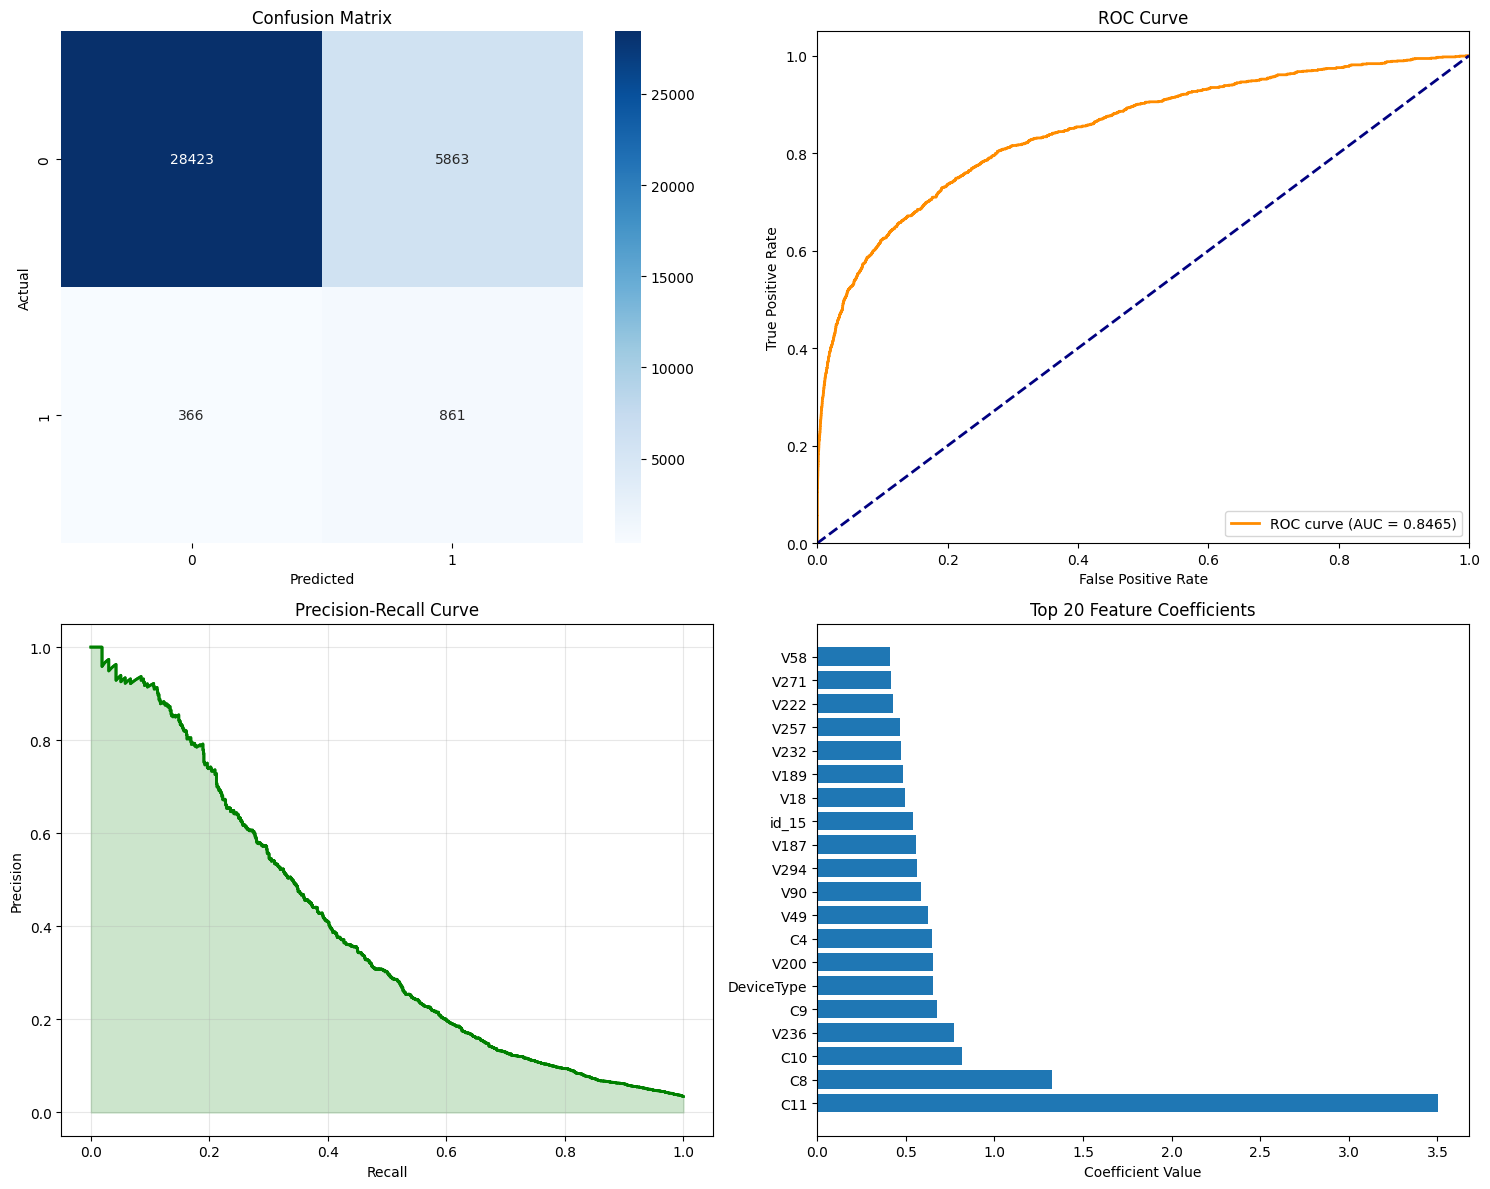

СРАВНЕНИЕ МОДЕЛЕЙ

          Model  ROC-AUC  F1-Score   pr_auc
     Base Model 0.843906  0.211871 0.385146
Optimized Model 0.846475  0.216577 0.389208

Лучшая модель сохранена как 'best_logreg.pkl'


In [ ]:
# Метрики
print("\nРезультаты оптимизированной модели:")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best):.4f}")
print(f"pr_auc: {average_precision_score(y_test, y_pred_proba_best):.4f}")
print(f"Precision: {f1_score(y_test, y_pred_best):.4f}")
print(f"Recall: {f1_score(y_test, y_pred_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Non-Fraud', 'Fraud']))

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0,0], cmap='Blues')
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
roc_auc = roc_auc_score(y_test, y_pred_proba_best)

axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0,1].set_xlim([0.0, 1.0])
axes[0,1].set_ylim([0.0, 1.05])
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend(loc="lower right")

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_best)
axes[1,0].plot(recall, precision, color='green', lw=2)
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {average_precision_score(y_test, y_pred_proba_best):.4f})')
axes[1,0].fill_between(recall, precision, alpha=0.2, color='green')

# Feature Importance (коэффициенты логистической регрессии)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': best_model.named_steps['classifier'].coef_[0]
})
feature_importance = feature_importance.sort_values('coefficient', ascending=False)

top_features = feature_importance.head(20)
axes[1,1].barh(range(len(top_features)), top_features['coefficient'].values)
axes[1,1].set_yticks(range(len(top_features)))
axes[1,1].set_yticklabels(top_features['feature'].values)
axes[1,1].set_xlabel('Coefficient Value')
axes[1,1].set_title('Top 20 Feature Coefficients')

plt.tight_layout()
plt.show()

# Сравниваем подели
print("СРАВНЕНИЕ МОДЕЛЕЙ\n")

comparison = pd.DataFrame({
    'Model': ['Base Model', 'Optimized Model'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba),
        roc_auc_score(y_test, y_pred_proba_best)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_best)
    ],
    'pr_auc': [
        average_precision_score(y_test, y_pred_proba),
        average_precision_score(y_test, y_pred_proba_best)
    ]
})
print(comparison.to_string(index=False))

# Сохраняем лучшую модель
import joblib
joblib.dump(best_model, 'best_logreg.pkl')
print("\nЛучшая модель сохранена как 'best_logreg.pkl'")

# Байесовы сети

In [ ]:
print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train fraud rate: 0.03454441777133243
Test fraud rate: 0.03455072790245826


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Специальные преобразования для разных моделей
X_train_binary = (X_train_scaled > 0).astype(int)
X_test_binary = (X_test_scaled > 0).astype(int)
X_train_nonneg = np.abs(X_train_scaled)
X_test_nonneg = np.abs(X_test_scaled)

In [ ]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, f1_score, precision_score, recall_score)
print("Базовая модель")

def evaluate_model(model, X_train, X_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        'model': model,
        'roc_auc': roc_auc_score(y_test, y_proba),
        'f1': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'pr_auc': average_precision_score(y_test, y_proba),
        'recall': recall_score(y_test, y_pred),
        'y_pred': y_pred,
        'y_proba': y_proba
    }

# Обучаем базовые модели
base_results = {}

print("\nGaussianNB")
base_results['GaussianNB'] = evaluate_model(
    GaussianNB(), X_train_scaled, X_test_scaled, 'GaussianNB'
)
print(f"  ROC-AUC: {base_results['GaussianNB']['roc_auc']:.4f} | F1: {base_results['GaussianNB']['f1']:.4f} | pr_auc: {base_results['GaussianNB']['pr_auc']:.4f}")

print("\nBernoulliNB")
base_results['BernoulliNB'] = evaluate_model(
    BernoulliNB(), X_train_binary, X_test_binary, 'BernoulliNB'
)
print(f"  ROC-AUC: {base_results['BernoulliNB']['roc_auc']:.4f} | F1: {base_results['BernoulliNB']['f1']:.4f} | pr_auc: {base_results['BernoulliNB']['pr_auc']:.4f}")

print("\nComplementNB")
base_results['ComplementNB'] = evaluate_model(
    ComplementNB(), X_train_nonneg, X_test_nonneg, 'ComplementNB'
)
print(f"  ROC-AUC: {base_results['ComplementNB']['roc_auc']:.4f} | F1: {base_results['ComplementNB']['f1']:.4f} | pr_auc: {base_results['ComplementNB']['pr_auc']:.4f}")


Базовая модель

GaussianNB
  ROC-AUC: 0.7067 | F1: 0.0948 | pr_auc: 0.0657

BernoulliNB
  ROC-AUC: 0.7694 | F1: 0.1794 | pr_auc: 0.0959

ComplementNB
  ROC-AUC: 0.6838 | F1: 0.2269 | pr_auc: 0.1461


In [ ]:
print("Подбор параметров")

cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)  # Минимум фолдов

tuned_results = {}

#GaussianNB
print("\nGaussianNB (оптимизация)")
param_gaussian = {'var_smoothing': [1e-9, 1e-7, 1e-5]}
grid = GridSearchCV(GaussianNB(), param_gaussian, cv=cv, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train_scaled, y_train)
tuned_results['GaussianNB'] = evaluate_model(
    grid.best_estimator_, X_train_scaled, X_test_scaled, 'GaussianNB'
)
print(f"  Лучший var_smoothing: {grid.best_params_['var_smoothing']:.0e}")
print(f"  ROC-AUC: {tuned_results['GaussianNB']['roc_auc']} | F1: {tuned_results['GaussianNB']['f1']} | pr_auc: {tuned_results['GaussianNB']['pr_auc']}")

#BernoulliNB
print("\nBernoulliNB (оптимизация)")
param_bernoulli = {'alpha': [0.1, 0.5, 1.0], 'binarize': [0.0, 0.5]}
grid = GridSearchCV(BernoulliNB(), param_bernoulli, cv=cv, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train_binary, y_train)
tuned_results['BernoulliNB'] = evaluate_model(
    grid.best_estimator_, X_train_binary, X_test_binary, 'BernoulliNB'
)
print(f"  Лучшие параметры: {grid.best_params_}")
print(f"  ROC-AUC: {tuned_results['BernoulliNB']['roc_auc']} | F1: {tuned_results['BernoulliNB']['f1']} | pr_auc: {tuned_results['BernoulliNB']['pr_auc']}")

#ComplementNB
print("\nComplementNB (оптимизация)")
param_complement = {'alpha': [0.1, 0.5, 1.0]}
grid = GridSearchCV(ComplementNB(), param_complement, cv=cv, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train_nonneg, y_train)
tuned_results['ComplementNB'] = evaluate_model(
    grid.best_estimator_, X_train_nonneg, X_test_nonneg, 'ComplementNB'
)
print(f"  Лучший alpha: {grid.best_params_['alpha']}")
print(f"  ROC-AUC: {tuned_results['ComplementNB']['roc_auc']} | F1: {tuned_results['ComplementNB']['f1']} | pr_auc: {tuned_results['ComplementNB']['pr_auc']}")


Подбор параметров

GaussianNB (оптимизация)
  Лучший var_smoothing: 1e-05
  ROC-AUC: 0.7346459103468351 | F1: 0.13107452477531217 | pr_auc: 0.0833399623596461

BernoulliNB (оптимизация)
  Лучшие параметры: {'alpha': 1.0, 'binarize': 0.0}
  ROC-AUC: 0.7693634983087991 | F1: 0.17941565115254735 | pr_auc: 0.09592261471728111

ComplementNB (оптимизация)
  Лучший alpha: 1.0
  ROC-AUC: 0.6837741884614965 | F1: 0.22686832740213522 | pr_auc: 0.14611671302887502


In [ ]:
# Создаем сводную таблицу
summary_data = []
for model_name in ['GaussianNB', 'BernoulliNB', 'ComplementNB']:
    base = base_results[model_name]
    tuned = tuned_results[model_name]

    summary_data.append({
        'Модель': model_name,
        'ROC-AUC (базовая)': f"{base['roc_auc']:.4f}",
        'ROC-AUC (оптим.)': f"{tuned['roc_auc']:.4f}",
        'F1 (базовая)': f"{base['f1']:.4f}",
        'F1 (оптим.)': f"{tuned['f1']:.4f}",
        'pr_auc': f"{base['pr_auc']:.4f}",
        'pr_auc (оптим.)': f"{tuned['pr_auc']:.4f}",
        'Улучшение ROC': f"{(tuned['roc_auc']-base['roc_auc'])*100:+.2f}%"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))


      Модель ROC-AUC (базовая) ROC-AUC (оптим.) F1 (базовая) F1 (оптим.) pr_auc pr_auc (оптим.) Улучшение ROC
  GaussianNB            0.7067           0.7346       0.0948      0.1311 0.0657          0.0833        +2.79%
 BernoulliNB            0.7694           0.7694       0.1794      0.1794 0.0959          0.0959        +0.00%
ComplementNB            0.6838           0.6838       0.2269      0.2269 0.1461          0.1461        +0.00%



Лучшая модель: BernoulliNB
ROC-AUC: 0.7694
F1-Score: 0.1794
pr_auc: 0.0959
Precision: 0.1094
Recall: 0.4980

Матрица ошибок:
 [[29313  4973]
 [  616   611]]


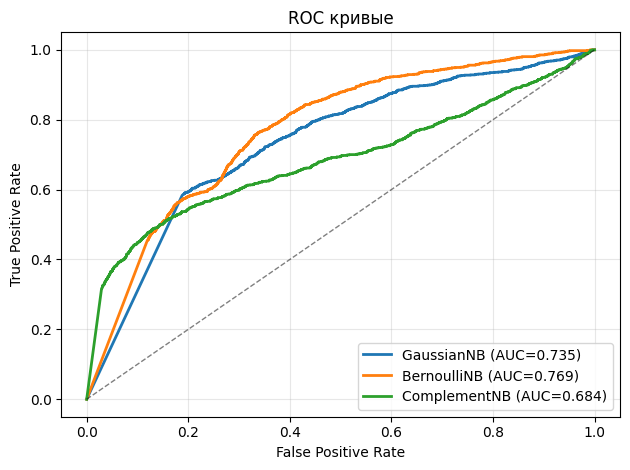

In [ ]:
best_model_name = max(tuned_results, key=lambda x: tuned_results[x]['roc_auc'])
best_results = tuned_results[best_model_name]

print(f"\nЛучшая модель: {best_model_name}")
print(f"ROC-AUC: {best_results['roc_auc']:.4f}")
print(f"F1-Score: {best_results['f1']:.4f}")
print(f"pr_auc: {best_results['pr_auc']:.4f}")
print(f"Precision: {best_results['precision']:.4f}")
print(f"Recall: {best_results['recall']:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_test, best_results['y_pred'])
print('\nМатрица ошибок:\n',cm)

# График 1: ROC-кривые всех моделей

for name in tuned_results:
    fpr, tpr, _ = roc_curve(y_test, tuned_results[name]['y_proba'])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={tuned_results[name]['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC кривые')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

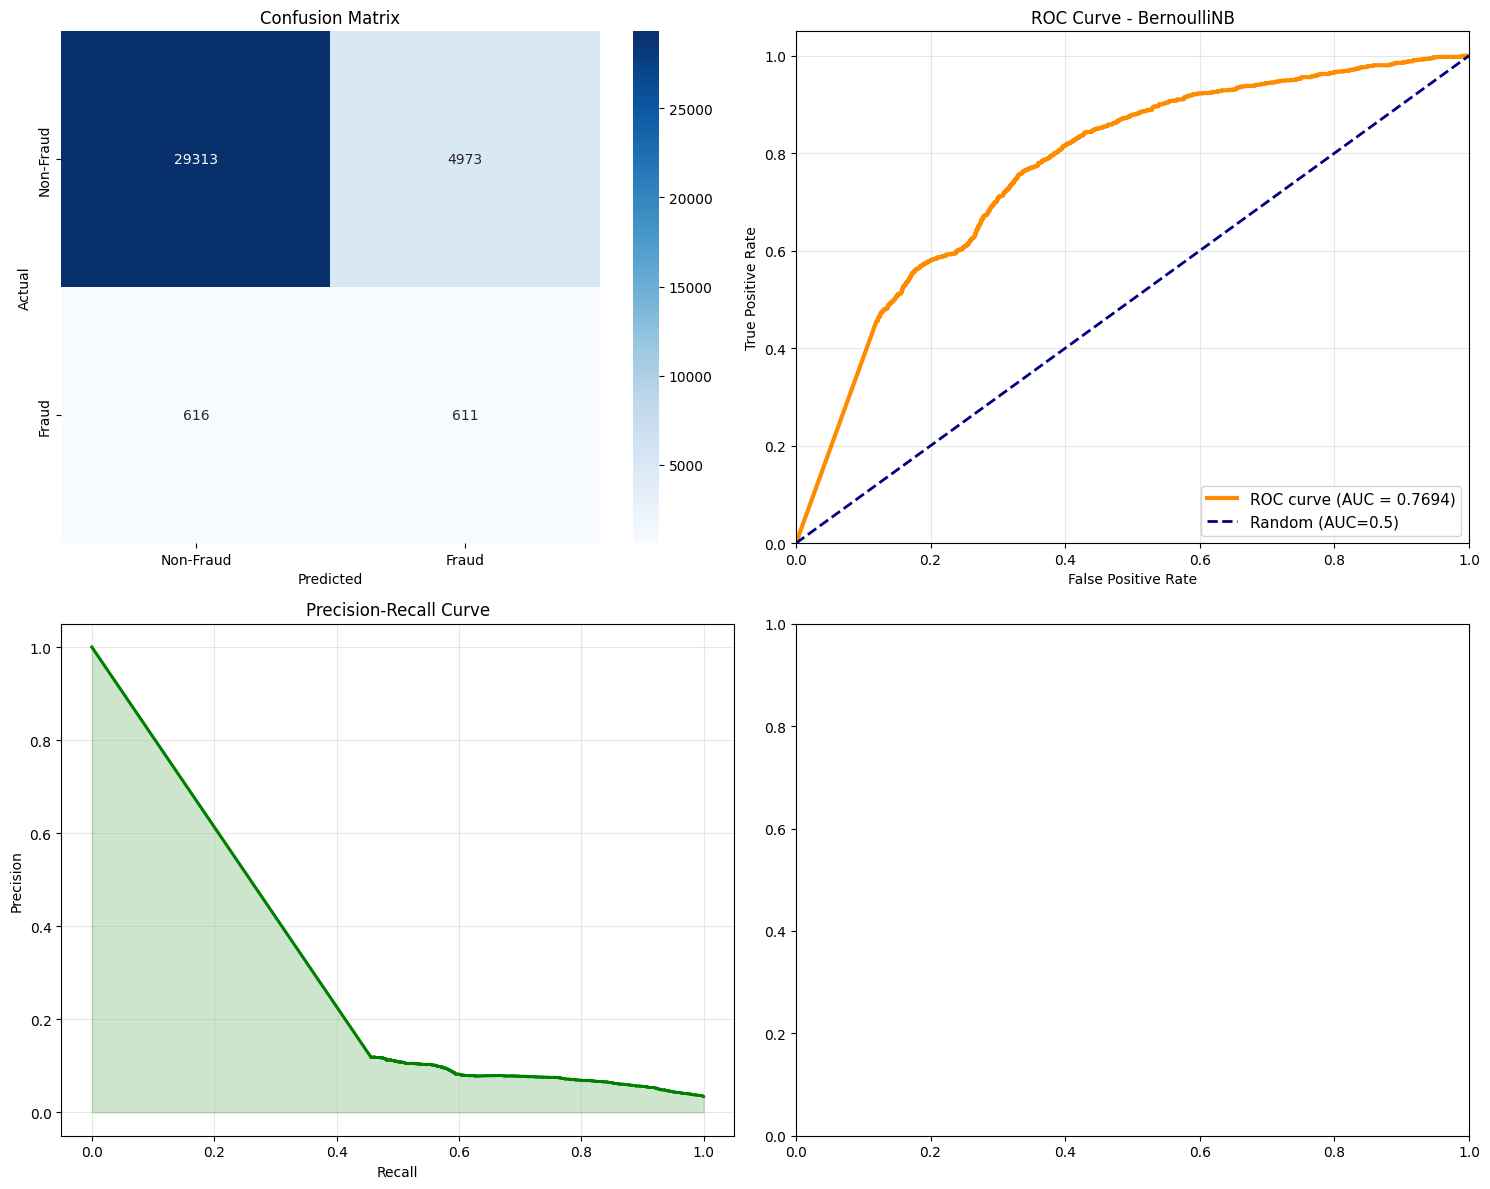


Лучшая модель сохранена как 'best_guess.pkl'


In [ ]:
from sklearn.metrics import precision_recall_curve, auc
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

cm = confusion_matrix(y_test, best_results['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0, 0], cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])
axes[0,0].set_title(f'Confusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, best_results['y_proba'])
roc_auc = best_results['roc_auc']

axes[0,1].plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC=0.5)')
axes[0,1].set_xlim([0.0, 1.0])
axes[0,1].set_ylim([0.0, 1.05])
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title(f'ROC Curve - {best_model_name}')
axes[0,1].legend(loc="lower right", fontsize=11)
axes[0,1].grid(True, alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test,  best_results['y_proba'])
axes[1,0].plot(recall, precision, color='green', lw=2)
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve')
axes[1,0].grid(True, alpha=0.3)

axes[1,0].plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {best_results['pr_auc']:.4f})')
axes[1,0].fill_between(recall, precision, alpha=0.2, color='green')

plt.tight_layout()
plt.show()

# Сохраняем лучшую модель
import joblib
joblib.dump(best_model, 'best_guess.pkl')
print(f"\nЛучшая модель сохранена как 'best_guess.pkl'")